In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import SubsetRandomSampler, DataLoader
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from collections import OrderedDict
import matplotlib.pyplot as plt
import os

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
epochs = 300
FTRAIN = 'data/training.csv'
FTEST = 'data/test.csv'

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

class cnn_model(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding='same')
        self.conv2 = nn.Conv2d(32, 32, 3)
        self.maxpool1 = nn.MaxPool2d(2)
        self.dropout1 = nn.Dropout(0.2)
        self.conv3 = nn.Conv2d(32, 64, 3, padding='same')
        self.conv4 = nn.Conv2d(64, 64, 3)
        self.conv5 = nn.Conv2d(64,128,3,padding='same')
        self.conv6 = nn.Conv2d(128,128,3)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(12800, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 30)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = torch.relu(self.conv5(x))
        x = torch.relu(self.conv6(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = self.flatten(x)
        x = torch.relu(self.fc(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

class Dataset2d(torch.utils.data.Dataset):
    def __init__(self, test=False, cols=None):
        fname = FTEST if test else FTRAIN
        self.test = test
        df = pd.read_csv(fname)

        df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

        # 提取 特定欄位 相關的數據
        if cols:
            df = df[list(cols) + ['Image']]
            
        print(df.count()) # 資料集的筆數
        df = df.dropna()  # 刪除其中缺少值的資料

        self.X = np.vstack(df['Image'].values) / 255. # 將像素值進行歸一化 [0, 1]
        self.X = self.X.astype(np.float32) # 轉換資料型態

        if not test: # 只有 FTRAIN 有目標的標籤(label)
            self.y = df[df.columns[:-1]].values
            self.y = (self.y - 48) / 48
            self.X, self.y = shuffle(self.X, self.y, random_state=42) # 對資料進行 洗牌
            self.y = self.y.astype(np.float32)
        else:
            self.y = None
        #self.X = self.X.reshape(-1, 1, 96, 96)
        self.X = self.X.reshape(-1, 96, 96, 1) # 轉換成 Conv2D的卷積層 的 input shape
        self.X = self.X.transpose((0,3,1,2))
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if not self.test:
            y = torch.tensor(self.y[idx],dtype=torch.float32)
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X,y
        else:
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X

def train(device,train_loader, model, criterion, optimizer):
    losses = AverageMeter()
   
    model.train()

    for i, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # compute output
        
        output = model(input)
        loss = criterion(output, target)
        
        losses.update(loss.item(), input.size(0))
        
        # compute gradient and do optimizing step
        
        loss.backward()
        optimizer.step()

    log = OrderedDict([('loss', losses.avg),])

    return log

def validate(device,train_loader, model, criterion):
    losses = AverageMeter()
   
    model.eval()
    with torch.no_grad():
        for i, (input, target) in enumerate(train_loader): 
            input = input.to(device)
            target = target.to(device)

            # compute output
            
            output = model(input)
            loss = criterion(output, target)
            
           
            losses.update(loss.item(), input.size(0))
                       

    log = OrderedDict([('loss', losses.avg),])

    return log




left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

/Users/brainma/anaconda3/envs/dle/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch:1/300 Train:0.08337	val:0.00990

Epoch:2/300 Train:0.02899	val:0.00739

Epoch:3/300 Train:0.01967	val:0.00731

Epoch:4/300 Train:0.01545	val:0.00633

Epoch:5/300 Train:0.01362	val:0.00568

Epoch:6/300 Train:0.01236	val:0.00579

Epoch:7/300 Train:0.01145	val:0.00589

Epoch:8/300 Train:0.01041	val:0.00540

Epoch:9/300 Train:0.01032	val:0.00627

Epoch:10/300 Train:0.01009	val:0.00472

Epoch:11/300 Train:0.00962	val:0.00459

Epoch:12/300 Train:0.00926	val:0.00669

Epoch:13/300 Train:0.00900	val:0.00442

Epoch:14/300 Train:0.00883	val:0.00683

Epoch:15/300 Train:0.00857	val:0.00520

Epoch:16/300 Train:0.00840	val:0.00570

Epoch:17/300 Train:0.00813	val:0.00430

Epoch:18/300 Train:0.00818	val:0.00578

Epoch:19/300 Train:0.00795	val:0.00480

Epoch:20/300 Train:0.00765	val:0.00500

Epoch:21/300 Train:0.00741	val:0.00521

Epoch:22/300 Train:0.00740	val:0.00455

Epoch:23/300 Train:0.00751	val:0.00472

Epoch:24/300 Train:0.00730	val:0.00592

Epoch:25/300 Train:0.00740	val:0.00461

Epoch:26/

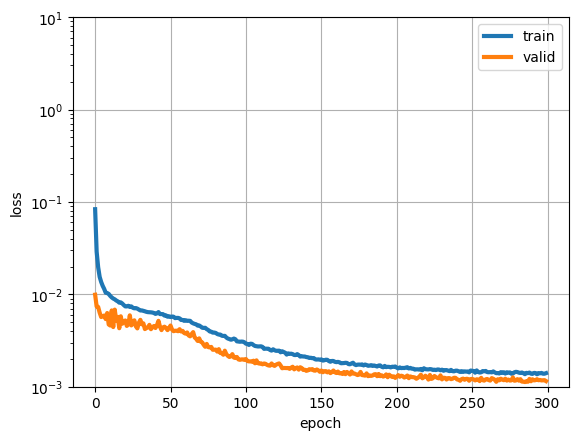

In [2]:
model2 = cnn_model().to(device)
model2 = nn.DataParallel(model2)
dataset = Dataset2d()
dataSize = len(dataset)
indices = list(range(dataSize))
split = int(np.floor(0.2 * dataSize))
train_idx , val_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)
train_loader = DataLoader(dataset, batch_size=128, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=128, sampler=val_sampler)
train_log = list()
val_log = list()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.001)
#optimizer = optim.SGD(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.01,momentum=0.9, nesterov=True)
criterion = nn.MSELoss().to(device)

for epoch in range(epochs):
    train_log.append(train(device, train_loader,model2,criterion,optimizer)['loss'])
    val_log.append(validate(device, val_loader,model2,criterion)['loss'])
    print("Epoch:{}/{} Train:{:.5f}\tval:{:.5f}\n".format(epoch + 1 ,epochs, train_log[-1], val_log[-1]))
                                                                                      
torch.save(model2, os.path.join('model2_faceKeyPoint_'+ str(epochs) + '.pt'))
#torch.save(model2.state_dict(), os.path.join('model2_faceKeyPoint_'+ str(epochs) + '.pt'))
loss = train_log
val_loss = val_log

plt.plot(loss, linewidth=3, label='train')
plt.plot(val_loss, linewidth=3, label='valid')
plt.grid()
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.ylim(1e-3, 1e+1)
plt.yscale('log') 
plt.show()

left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

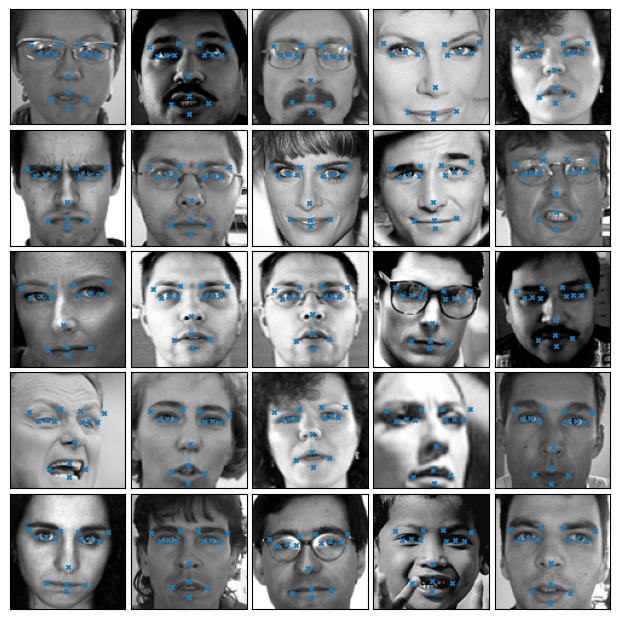

In [ ]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96) 
    axis.imshow(img, cmap='gray') 
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)

testset = Dataset2d(test=True)
epoch_num = 300
test_loader = DataLoader(testset, batch_size=128)   
model = torch.load(os.path.join('model2_faceKeyPoint_'+ str(epoch_num) + '.pt'))


input = None
y_pred2 = None
with torch.no_grad():
    for i, (input) in enumerate(test_loader): 
        input = input.to(device)
        y_pred2 = model2(input).cpu().numpy()
        input = input.cpu().numpy()


fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


for i in range(25):
    ax = fig.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    plot_sample (input[i], y_pred2[i], ax)

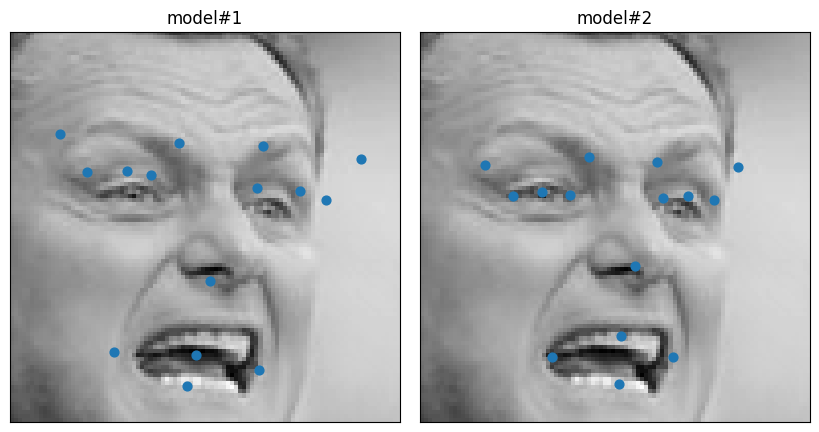

In [82]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)       # 圖像是 96x96
    axis.imshow(img, cmap='gray') # 以灰階來顯示
    
    # 模型預測出來的 15個臉部關鍵點 列印在圖像上
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='o', s=40)
    
fig = plt.figure(figsize=(8, 8))

idx = 15 # 找一張圖像 來比較兩個模型 預測的結果

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# 第一個 模型

ax = fig.add_subplot(1, 2, 1, xticks=[], yticks=[])
ax.set_title('model#1')
plot_sample(input[idx], y_pred[idx], ax)

# 第二個 模型
ax = fig.add_subplot(1, 2, 2, xticks=[], yticks=[])
ax.set_title('model#2')
plot_sample(input[idx], y_pred2[idx], ax)
 
plt.show()

In [14]:
import pandas as pd

df = pd.read_csv('data/test.csv')
df.head()

,ImageId,Image
0,1,182 183 182 182 180 180 176 169 156 137 124 10...
1,2,76 87 81 72 65 59 64 76 69 42 31 38 49 58 58 4...
2,3,177 176 174 170 169 169 168 166 166 166 161 14...
3,4,176 174 174 175 174 174 176 176 175 171 165 15...
4,5,50 47 44 101 144 149 120 58 48 42 35 35 37 39 ...


In [15]:
print(df.shape)
image_cols = list(df.columns)[-1]
print(image_cols)


(1783, 2)
Image


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def string2image(string):
    """converts a string to a numpy array."""
    return np.array([int(item) for item in string.split()]).reshape((96, 96))

def plot_faces(nrows=5, ncols=5):
    """randomly displays some faces from the training data."""
    selection = np.random.choice(df.index, size=(nrows*ncols), replace=false)
    image_strings = df.loc[selection]['image']
    fig, axes = plt.subplots(figsize=(10, 10), nrows=nrows, ncols=ncols)
    for string, ax in zip(image_strings, axes.ravel()):
        ax.imshow(string2image(string), cmap='gray')
        ax.axis('off')

def plot_faces_with_keypoints(nrows=5, ncols=5):
    """Randomly displays some faces from the training data with their keypoints."""
    selection = np.random.choice(df.index, size=(nrows*ncols), replace=False)
    image_strings = df.loc[selection]['Image']
    keypoint_cols = list(df.columns)[:-1]
    keypoints = df.loc[selection][keypoint_cols]
    fig, axes = plt.subplots(figsize=(10, 10), nrows=nrows, ncols=ncols)
    for string, (iloc, keypoint), ax in zip(image_strings, keypoints.iterrows(), axes.ravel()):
        xy = keypoint.values.reshape((15, 2))
        ax.imshow(string2image(string), cmap='gray')
        ax.plot(xy[:, 0], xy[:, 1], 'ro')
        ax.axis('off')

In [17]:
fully_annotated = df.dropna()
fully_annotated.shape

(1783, 2)

In [18]:
X = np.stack([string2image(string) for string in fully_annotated['Image']]).astype(np.float32)[:, :, :, np.newaxis]
#y = np.vstack(fully_annotated[fully_annotated.columns[:-1]].values)



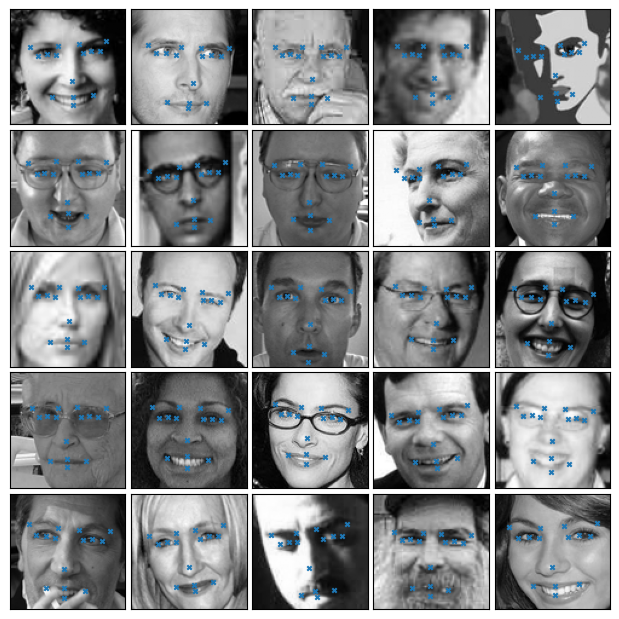

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn

class cnn_model(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding='same')
        self.conv2 = nn.Conv2d(32, 32, 3)
        self.maxpool1 = nn.MaxPool2d(2)
        self.dropout1 = nn.Dropout(0.2)
        self.conv3 = nn.Conv2d(32, 64, 3, padding='same')
        self.conv4 = nn.Conv2d(64, 64, 3)
        self.conv5 = nn.Conv2d(64,128,3,padding='same')
        self.conv6 = nn.Conv2d(128,128,3)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(12800, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 30)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = torch.relu(self.conv5(x))
        x = torch.relu(self.conv6(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = self.flatten(x)
        x = torch.relu(self.fc(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


def plot_sample(x, y, axis):
    img = x.reshape(96, 96) 
    axis.imshow(img, cmap='gray') 
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)

def plot_faces_with_keypoints_and_predictions(model, nrows=5, ncols=5, model_input='flat'):
    """Plots sampled faces with their truth and predictions."""
    selection = np.random.choice(np.arange(X.shape[0]), size=(nrows*ncols), replace=False)
    fig = plt.figure(figsize=(6, 6))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
    #fig, axes = plt.subplots(figsize=(10, 10), nrows=nrows, ncols=ncols)
    model.eval()
    with torch.no_grad():
        for ind, i in zip(selection, range(25)):
            img = X[ind, :, :, 0]/255
            img2 = img.reshape(-1, 96, 96, 1) 
            img2 = torch.tensor(img2.transpose((0,3,1,2)))
            img2 = img2.to(device)
            predictions = model(img2).cpu().numpy()
            #xy_predictions =predictions.reshape(15, 2)
            #ax.imshow(img, cmap='gray')
            #ax.plot(xy_predictions[:, 0]*48+48, xy_predictions[:, 1]*48+48, 'bo')
            #ax.axis('off')
            
            ax = fig.add_subplot(5, 5, i+ 1, xticks=[], yticks=[])
            plot_sample (img, predictions[0], ax)


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model2 = torch.load('model2_faceKeyPoint_300.pt', map_location=device,weights_only=False)
plot_faces_with_keypoints_and_predictions(model2)



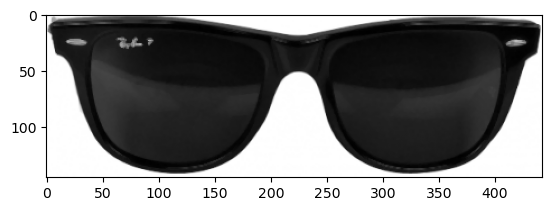

In [33]:
import skimage.color
from skimage.filters import median
import matplotlib.pyplot as plt
import cv2
moustache = cv2.imread('sunglasses_3.png',cv2.IMREAD_COLOR)
#moustache = plt.imread('moustache-png-by-spoonswagging-on-deviantart-1.png')
moustache = skimage.color.rgb2gray(moustache)
moustache = median(moustache)
plt.imshow(moustache, cmap='gray')

In [34]:
from skimage import measure
moustache_contour = measure.find_contours(moustache, 0.8)[0]
moustache_contour -= np.array([250, 250])


In [35]:
def plot_scaled_moustache(ax, center_xy, dx):
    """Plots a moustache scaled by its width, dx, on current ax."""
    moustache_scaled = moustache_contour.copy()
    moustache_scaled -= moustache_contour.min(axis=0)
    moustache_scaled /= moustache_scaled.max(axis=0)[1]
    deltas = moustache_scaled.max(axis=0) - moustache_scaled.min(axis=0)
    moustache_scaled -= np.array([deltas[0]/2, deltas[1]/2])
    moustache_scaled *= dx
    moustache_scaled += center_xy[::-1]
    ax.fill(moustache_scaled[:, 1], moustache_scaled[:, 0], "cyan", linewidth=4)

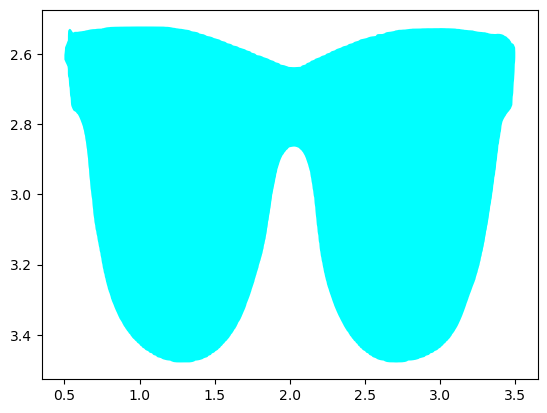

In [36]:
ax = plt.gca()
plot_scaled_moustache(ax, np.array([2, 3]), dx=3)
ax.invert_yaxis()

In [48]:
import numpy as np
def draw_moustache(predicted_points, ax):
    """Draws a moustache using the predicted face points."""
    left_eye = predicted_points[1, :] * 48 + 48
    right_eye = predicted_points[2, :] * 48 + 48

    dx = 2.2 * np.linalg.norm(right_eye - left_eye)  # 放大一點眼鏡寬度
    center_xy = (left_eye + right_eye) / 2

    plot_scaled_moustache(ax, center_xy, dx)

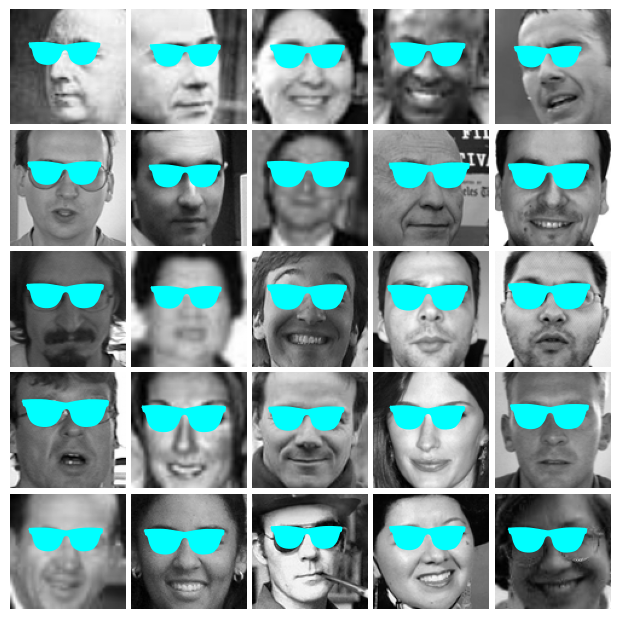

In [49]:
def plot_faces_with_moustaches(X, model, nrows=5, ncols=5):
    """Plots sampled faces with their truth and predictions."""
    selection = np.random.choice(np.arange(X.shape[0]), size=(nrows*ncols), replace=False)
    fig = plt.figure(figsize=(6, 6))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
    model.eval()
    with torch.no_grad():
        for ind, i in zip(selection, range(25)):
            img = X[ind, :, :, 0]
            img2 = img/255
            img2 = img2.reshape(-1, 96, 96, 1) 
            img2 = torch.tensor(img2.transpose((0,3,1,2)))
            img2 = img2.to(device)
            predictions = model(img2).cpu().numpy()
           
            xy_predictions = predictions[0].reshape(15, 2)
            ax = fig.add_subplot(5, 5, i+ 1, xticks=[], yticks=[])
            ax.imshow(img, cmap='gray')
            draw_moustache(xy_predictions, ax)
            ax.axis('off')
           
plot_faces_with_moustaches(X,model2)

In [50]:
from skimage.io import imread

portraits = {'GertrudeStein.jpeg','Hans_Holbein,_the_Younger_-_Sir_Thomas_More_-_Google_Art_Project.jpg',
             'Girl_with_Cherries_Metropolitan_Museum_of_Art.jpg','Martin_Luther,_1529.jpg','Mona_Lisa.jpg',
             'Pierre-Auguste_Renoir_110.jpg','The_Blue_Boy.jpg', 'Thomas_Kerrich_(1748-1828)_by_Pompeo_Batoni.jpg'}
pics = {}
for p in portraits:
    if p not in pics:
        pics[p] = imread(p)

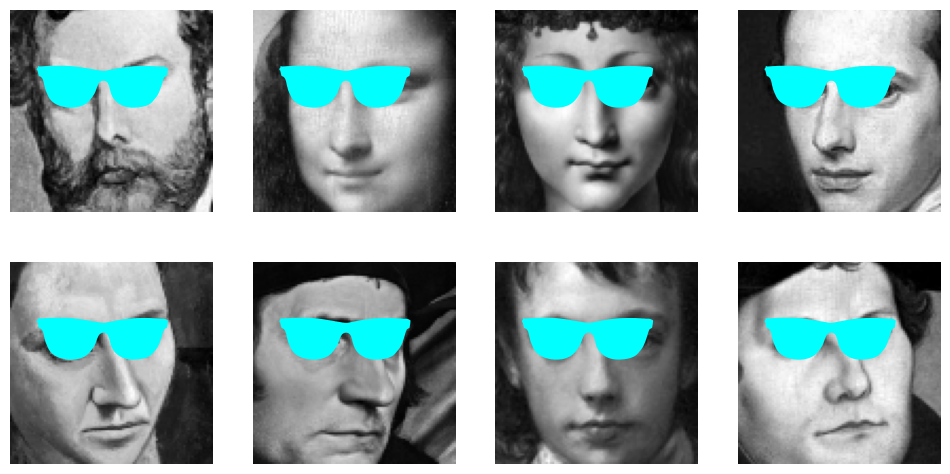

In [51]:
import cv2
import torch
from torch import nn
import skimage
from torch.nn.parallel import DataParallel
from torch.serialization import add_safe_globals
face_cascade = cv2.CascadeClassifier('data/haarcascade_frontalface_default.xml')
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
class cnn_model(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding='same')
        self.conv2 = nn.Conv2d(32, 32, 3)
        self.maxpool1 = nn.MaxPool2d(2)
        self.dropout1 = nn.Dropout(0.2)
        self.conv3 = nn.Conv2d(32, 64, 3, padding='same')
        self.conv4 = nn.Conv2d(64, 64, 3)
        self.conv5 = nn.Conv2d(64,128,3,padding='same')
        self.conv6 = nn.Conv2d(128,128,3)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(12800, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 30)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = torch.relu(self.conv5(x))
        x = torch.relu(self.conv6(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = self.flatten(x)
        x = torch.relu(self.fc(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x
add_safe_globals([DataParallel])
model2 = torch.load('model2_faceKeyPoint_300.pt', map_location=device, weights_only=False)

model2.eval()
with torch.no_grad():
    for img, ax in zip(pics.values(), axes.ravel()):
        gray = (skimage.color.rgb2gray(img) * 255).astype(dtype='uint8')
        bounding_boxes = face_cascade.detectMultiScale(gray, 1.25, 6)
        for (x,y,w,h) in bounding_boxes:
            roi_gray = gray[y:y+h, x:x+w]
            roi_rescaled = skimage.transform.resize(roi_gray, (96, 96))
            img2 = roi_rescaled/255
            img2 = img2.reshape(-1, 96, 96, 1) 
            img2 = torch.tensor(img2.transpose((0,3,1,2))).float()
            img2 = img2.to(device)
            predictions = model2(img2).cpu().numpy()
            xy_predictions = predictions.reshape(15, 2)
            ax.imshow(roi_rescaled, cmap='gray')
            draw_moustache(xy_predictions, ax)
        ax.axis('off')

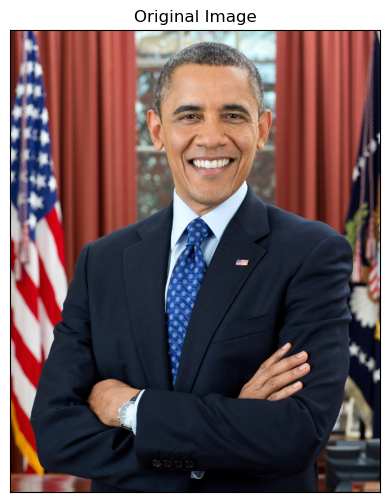

In [52]:
image = cv2.imread('Obama.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
fig = plt.figure(figsize = (6,6))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.set_title('Original Image')
ax1.imshow(image)

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
face_cascade = cv2.CascadeClassifier('data/haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, 1.25, 6)
print('Number of faces detected:', len(faces))
image_with_detections = np.copy(image)

for (x,y,w,h) in faces:
    
    cv2.rectangle(image_with_detections, (x,y), (x+w,y+h), (255,0,0), 3)
    



fig = plt.figure(figsize = (6,6))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.set_title('Image with Face Detection')
ax1.imshow(image_with_detections)

In [ ]:
image_with_detections = np.copy(image)   

for (x,y,w,h) in faces:
    cv2.rectangle(image_with_detections, (x,y), (x+w,y+h),(255,0,0), 3)  
    
eye_cascade = cv2.CascadeClassifier('data/haarcascade_eye.xml')

eyes = eye_cascade.detectMultiScale(gray, 1.2, 6)

for (x,y,w,h) in eyes:
    
    
    cv2.rectangle(image_with_detections, (x,y), (x+w, y+h), (0,255,0), 3)
    
# Plot 檢測到臉部和眼睛的 圖像

fig = plt.figure(figsize = (6,6))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.set_title('Image with Face and Eye Detection')
ax1.imshow(image_with_detections)

In [ ]:
import cv2
import time 

#face/eye detection with your laptop camera
def laptop_camera_go():
    # video capturer
    cv2.namedWindow("face detection activated")
    vc = cv2.VideoCapture(0)

    # Read first frame
    if vc.isOpened(): 
        rval, frame = vc.read()
    else:
        rval = False
    face_cascade = cv2.CascadeClassifier('data/haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier('data/haarcascade_eye.xml')
    
    #video stream open
    while rval:
        # Plot the image from camera with all the face and eye detections marked
        # Detect the faces and eyes in image
        faces = face_cascade.detectMultiScale(frame, 1.25, 6)
        eyes = eye_cascade.detectMultiScale(frame, 1.1, 12)
        for (x,y,w,h) in faces:
            cv2.rectangle(frame, (x,y), (x+w,y+h),(255,0,0), 3)
            
        for (x,y,w,h) in eyes:
            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 3)
            
        cv2.imshow("face detection activated", frame)
        
        # quit- by pressing any key
        key = cv2.waitKey(20)
        if key > 0: 
            # Destroy windows 
            cv2.destroyAllWindows()
            
            # 確保 OSx上的 窗口關閉
            for i in range (1,5):
                cv2.waitKey(1)
            return
        
        # Read next frame
        time.sleep(0.05)    # control frame rate - default 20 frames per sec - default 20 frames per sec
        rval, frame = vc.read()   

laptop_camera_go()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('test_image_1.jpg')

# 圖像副本轉換為 RGB 顏色

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# copy 圖像的數組 副本

image_with_noise = np.asarray(image)

# 創建噪聲 - 這裡我們添加從高斯分佈中 Gaussian distribution 隨機採樣的噪聲

noise_level = 40
noise = np.random.randn(image.shape[0],image.shape[1],image.shape[2])*noise_level

# 噪聲添加到陣列圖像副本
image_with_noise = image_with_noise + noise

# 轉換回 uint8 格式
image_with_noise = np.asarray([np.uint8(np.clip(i,0,255)) for i in image_with_noise])

# Plot our noisy image!
fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.set_title('Noisy Image')
ax1.imshow(image_with_noise)

In [ ]:
# RGB圖像 轉換為 灰度 grayscale

gray_noise = cv2.cvtColor(image_with_noise, cv2.COLOR_RGB2GRAY)

# xml文件中 提取 預先訓練的 pre-trained 面部檢測器

face_cascade = cv2.CascadeClassifier('data/haarcascade_frontalface_default.xml')

# 檢測圖像中的面部

faces = face_cascade.detectMultiScale(gray_noise, 4, 6)

# Print 圖像中檢測到的面部數量

print('Number of faces detected:', len(faces))

# Copy 製作原始圖像的副本以繪製面部檢測

image_with_detections = np.copy(image_with_noise)

# 獲取每個檢測到的面部的邊界框

for (x,y,w,h) in faces:
    
    # 檢測圖像中添加紅色邊界框
    cv2.rectangle(image_with_detections, (x,y), (x+w,y+h), (255,0,0), 3)
    

# Display 顯示 檢測 圖像

fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.set_title('Noisy Image with Face Detections')
ax1.imshow(image_with_detections)

In [ ]:
denoised = cv2.fastNlMeansDenoisingColored(image_with_noise, None, 17, 25,7, 21)

# Plot our noisy image!
fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.set_title('De-Noised Image')
ax1.imshow(denoised)

In [ ]:
gray_noise = cv2.cvtColor(denoised, cv2.COLOR_RGB2GRAY)

# xml文件中 提取 預先訓練的  pre-trained 面部檢測器 face detector

face_cascade = cv2.CascadeClassifier('data/haarcascade_frontalface_default.xml')

# 檢測圖像中的面部

faces = face_cascade.detectMultiScale(gray_noise, 4, 6)

# Print 圖像中檢測到的面部數量

print('Number of faces detected:', len(faces))

# copy 製作原始圖像的副本以繪製面部檢測

image_with_detections = np.copy(denoised)

# 獲取每個檢測到的面部的邊界框

for (x,y,w,h) in faces:
    # 檢測圖像中添加紅色邊界框
    
    cv2.rectangle(denoised, (x,y), (x+w,y+h), (255,0,0), 3)
    

# Display 檢測 圖像  顯示

fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.set_title('De-Noised Image with Face Detections')
ax1.imshow(denoised)

In [ ]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread('fawzia.jpg')

# 轉換為RGB色彩

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 轉換為灰度

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)  

# 執行 Canny edge detection

canny = cv2.Canny(gray,100,200)

# Dilate 擴大圖像 以 放大邊緣

edges = cv2.dilate(canny, None)


# Plot RGB 和 邊緣檢測圖像
fig = plt.figure(figsize = (15,15))
ax0.set_title('Original Image')
ax0 = fig.add_subplot(111)
ax0.set_xticks([])
ax0.set_yticks([])
ax0.imshow(image, cmap='gray')

fig = plt.figure(figsize = (15,15))
ax1 = fig.add_subplot(121)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Canny Edge')
ax1.imshow(canny, cmap='gray')

ax2 = fig.add_subplot(122)
ax2.set_title('Canny + dilate Edges')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.imshow(edges, cmap='gray')

In [ ]:
image = cv2.imread('fawzia.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

blur = np.copy(gray)
kernal = np.ones((4,4), dtype=np.float32)/16
blur = cv2.filter2D(blur, -1, kernal)


## Canny edge detection 邊緣檢測 並 顯示輸出

edges = cv2.Canny(blur, 100, 200)
edges = cv2.dilate(edges, None)

fig = plt.figure(figsize=(15,15))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.set_title('Blurred Image')
ax1.imshow(blur, cmap='gray')
ax2.set_title('Canny Edges')
ax2.imshow(edges, cmap='gray')

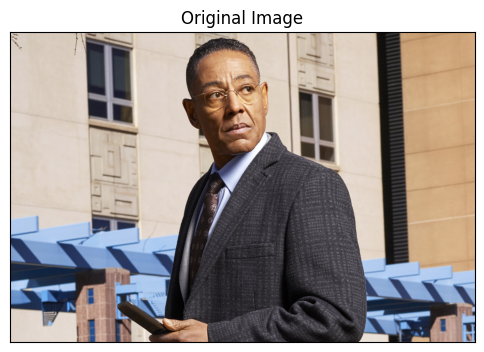

In [7]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread('gus.jpg')

# 圖像轉換為 RGB色彩

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display 顯示圖像

fig = plt.figure(figsize = (6,6))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Original Image')
ax1.imshow(image)

Number of faces detected: 1


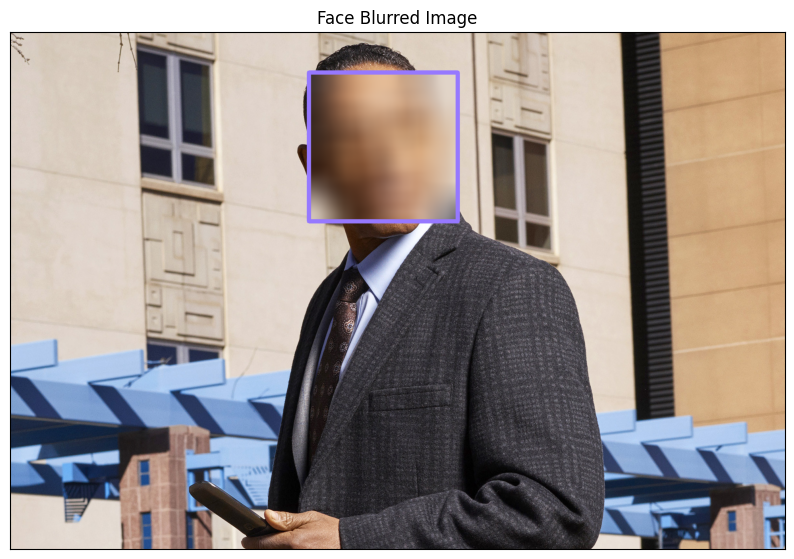

In [8]:
import numpy as np

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

face_cascade = cv2.CascadeClassifier('data/haarcascade_frontalface_default.xml')

faces = face_cascade.detectMultiScale(gray,4,4)
print('Number of faces detected:', len(faces))
image_blurred = np.copy(image)

kernal = np.ones((100,100), dtype=np.float32)/10000

## 平均濾波器模糊 - 每個檢測到的面部周圍的邊界框 並 顯示結果 

for (x,y,w,h) in faces:
    
    image_blurred[y:y+w,x:x+h] = cv2.filter2D(image_blurred[y:y+w,x:x+h], -1, kernal)
    cv2.rectangle(image_blurred, (x,y), (x+w,y+h),(150,120,255), 10)

# Display 顯示圖像

fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Face Blurred Image')
plt.imshow(image_blurred)

In [ ]:
import cv2
import time 

def laptop_camera_go():
    # 創建視頻捕獲器 video capturer
    
    cv2.namedWindow("face detection activated")
    vc = cv2.VideoCapture(0)

    # 嘗試獲得 first frame
    
    if vc.isOpened(): 
        rval, frame = vc.read()
    else:
        rval = False
    
    # 保持視頻流暢通  video stream open
    
    while rval:
        # Plot image 標記 detections marked 為 檢測的攝像機繪製圖像
        
        faces = face_cascade.detectMultiScale(frame, 1.1,6)
        
        for (x,y,w,h) in faces:
            frame[y:y+w,x:x+h] = cv2.filter2D(frame[y:y+w,x:x+h], -1, kernal)
            cv2.rectangle(frame, (x,y), (x+w,y+h),(255,120,150), 5)
        
        cv2.imshow("face detection activated", frame)
        
        # 退出功能 - 按任意鍵退出 筆記本電腦視頻 laptop video
        
        key = cv2.waitKey(20)
        if key > 0: # Exit 按任意鍵 退出 
            
            # Destroy windows
            cv2.destroyAllWindows()
            
            for i in range (1,5):
                cv2.waitKey(1)
            return
        
        # Read next frame
        
        time.sleep(0.05) # control frame rate - default 20 frames per sec 
        rval, frame = vc.read()
laptop_camera_go() 

KeyboardInterrupt: 

: 

In [11]:
import os
import argparse
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet
from torchvision.utils import save_image
from torch.utils.data import Subset
from matplotlib import pyplot as plt

# -----------------------------
# Utilities
# -----------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    # Apple Silicon (MPS)
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    #torch.cuda.manual_seed_all(seed)

# -----------------------------
# U-Net model
# -----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, n_classes=1, base_ch=64):
        super().__init__()
        self.down1 = DoubleConv(in_ch, base_ch)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(base_ch, base_ch*2)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(base_ch*2, base_ch*4)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(base_ch*4, base_ch*8)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_ch*8, base_ch*16)

        self.up4 = nn.ConvTranspose2d(base_ch*16, base_ch*8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_ch*16, base_ch*8)

        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_ch*8, base_ch*4)

        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_ch*4, base_ch*2)

        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_ch*2, base_ch)

        self.head = nn.Conv2d(base_ch, n_classes, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        d4 = self.dec4(torch.cat([u4, c4], dim=1))

        u3 = self.up3(d4)
        d3 = self.dec3(torch.cat([u3, c3], dim=1))

        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, c2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, c1], dim=1))

        logits = self.head(d1)
        return logits

# -----------------------------
# Dataset wrapper for binary masks
# -----------------------------
class OxfordPetSegBinary(Dataset):
    """
    Wrap OxfordIIITPet(split='trainval'/'test', target_types='segmentation')
    Convert trimap {1,2,3} -> binary mask {0,1} with (mask>1)->1
    """
    def __init__(self, root, split="trainval", image_size=256, download=True):
        self.ds = OxfordIIITPet(
            root=root, split=split, target_types="segmentation", download=download
        )
        self.ds = Subset(self.ds, range(300)) 
        self.img_transform = T.Compose([
            T.Resize((image_size, image_size), interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
        self.mask_transform = T.Resize((image_size, image_size), interpolation=T.InterpolationMode.NEAREST)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]  # PIL.Image, PIL.Image (mode='L', values in {1,2,3})
        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        mask_np = np.array(mask, dtype=np.uint8)  # still {1,2,3}
        bin_mask = (mask_np > 1).astype(np.float32)  # {0,1}
        bin_mask = torch.from_numpy(bin_mask).unsqueeze(0)  # (1,H,W)
        return img, bin_mask

# -----------------------------
# Loss / Metrics
# -----------------------------
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        # Dice (soft)
        num = 2.0 * (probs * targets).sum(dim=(2,3)) + self.smooth
        den = (probs + targets).sum(dim=(2,3)) + self.smooth
        dice = (num / den).mean()
        return bce + (1.0 - dice)

@torch.no_grad()
def dice_iou(logits, targets, thr=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    inter = (preds * targets).sum(dim=(2,3))
    union = (preds + targets - preds*targets).sum(dim=(2,3))
    dice = (2*inter / (preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + 1e-7)).mean().item()
    iou = (inter / (union + 1e-7)).mean().item()
    return dice, iou

# -----------------------------
# Training / Validation
# -----------------------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for imgs, masks in tqdm(loader) :
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou, n = 0.0, 0.0, 0.0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)
        dice, iou = dice_iou(logits, masks)
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_dice += dice * bs
        total_iou  += iou  * bs
        n += bs
    return total_loss / n, total_dice / n, total_iou / n

# -----------------------------
# Inference & saving masks
# -----------------------------
@torch.no_grad()
def run_inference(model, loader, device, out_dir, num_batches=3, thr=0.5):
    model.eval()
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    saved = 0
    for bidx, (imgs, masks) in enumerate(loader):
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > thr).float()

        # save a grid: [input, target, pred]
        for i in range(imgs.size(0)):
            mask= masks[i]
            mask = mask.to(device)
            img = ((imgs[i] * torch.tensor([0.229,0.224,0.225], device=device).view(3,1,1)) + 
                 torch.tensor([0.485,0.456,0.406], device=device).view(3,1,1)).clamp(0,1)
            img = img.to(device)
            grid = torch.cat([
                # denormalize image to [0,1]
                img,
                mask.repeat(3,1,1),
                preds[i].repeat(3,1,1),
            ], dim=2)  # concatenate along width
            save_image(grid.cpu(), out_dir / f"sample_{bidx:02d}_{i:02d}.png")
            saved += 1
        if bidx + 1 >= num_batches:
            break
    return saved

# -----------------------------
# Main (train / infer)
# -----------------------------
def main():
    '''
    parser = argparse.ArgumentParser()
    parser.add_argument("--root", type=str, default="./data", help="資料集下載與快取目錄")
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--img_size", type=int, default=256)
    parser.add_argument("--val_ratio", type=float, default=0.2)
    parser.add_argument("--save_dir", type=str, default="./runs_unet_pet")
    parser.add_argument("--infer_only", action="store_true", help="僅推論（需要已訓練權重）")
    parser.add_argument("--weights", type=str, default="", help="載入權重路徑（.pt）")
    parser.add_argument("--use_amp", action="store_true", help="啟用自動混合精度（訓練）")
    args = parser.parse_args()
    '''
    val_ratio = 0.1
    batch_size = 128
    infer_only = False
    weights = "./runs_unet_pet/best.pt"
    lr = 1e-3
    epochs = 20
    set_seed(42)
    infer_only = True

    device = get_device()
    print(f"Using device: {device}")
    save_dir = "./runs_unet_pet"
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # Dataset
    full_ds = OxfordPetSegBinary(root='./pet_seg_data', split="trainval", image_size=256, download=True)
    print(f"Dataset size: {len(full_ds)} images")    
    # 建立 train/val 切分
    val_len = max(1, int(len(full_ds) * val_ratio))
    train_len = len(full_ds) - val_len
    train_ds, val_ds = random_split(full_ds, [train_len, val_len], generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    # Model
    model = UNet(in_ch=3, n_classes=1, base_ch=64).to(device)

    # If inference only, load weights and run example predictions
    if infer_only:
        assert weights and os.path.exists(weights), "請提供有效的 --weights 權重檔路徑"
        ckpt = torch.load(weights, map_location=device)
        model.load_state_dict(ckpt["model"])
        print("Loaded weights.")
        saved = run_inference(model, val_loader, device, out_dir=save_dir / "preds", num_batches=3)
        print(f"Saved {saved} prediction samples to {save_dir/'preds'}")
        return

    # Training setup
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = BCEDiceLoss()
    best_iou = 0.0
    for epoch in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_dice, va_iou = validate(model, val_loader, criterion, device)

        print(f"[Epoch {epoch:02d}/{epochs}] "
              f"train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | dice={va_dice:.4f} | iou={va_iou:.4f}")

        # Save best
        if va_iou > best_iou:
            best_iou = va_iou
            ckpt = {
                "model": model.state_dict(),
                "epoch": epoch,
                "val_iou": va_iou,
            }
            torch.save(ckpt, save_dir / "best.pt")

    print(f"Training done. Best IoU = {best_iou:.4f}. Weights saved to {save_dir/'best.pt'}")

    # Quick inference preview
    ckpt = torch.load(save_dir / "best.pt", map_location=device)
    model.load_state_dict(ckpt["model"])
    saved = run_inference(model, val_loader, device, out_dir=save_dir / "preds", num_batches=3)
    print(f"Saved {saved} prediction samples to {save_dir/'preds'}")

if __name__ == "__main__":
    main()

Using device: mps
Dataset size: 300 images
Loaded weights.
Saved 30 prediction samples to runs_unet_pet/preds
